# Beyond BLAST Notebook

In [ ]:
ENV["JULIA_PKG_PRECOMPILE_AUTO"] = 0;
using Pkg
Pkg.activate("blast_code"; io=devnull)
Pkg.resolve(; io=devnull)
Pkg.instantiate(; io=devnull)

using Revise 

using Base.Threads, NPZ, DataInterpolations, Interpolations, FastChebInterp
using BenchmarkTools, FFTW, FastTransforms, Dates, TOML, Plots, Plots.Measures
using QuadGK, LaTeXStrings, Tullio, StaticArrays, LoopVectorization, LinearAlgebra
using Unitful, SpecialFunctions, DifferentialEquations, Cosmology, NumericalIntegration
using CSV, DataFrames, JSON, OrderedCollections
using MCIntegration
;

In [ ]:
include("blast_code/src/Blast.jl")
include("blast_code/src/blast_tutorials.jl")
include("blast_code/src/galaxy_galaxy.jl")
include("blast_code/src/shear_shear.jl")
include("blast_code/src/config.jl")
include("blast_code/src/paths.jl")
include("blast_code/src/plot_config.jl")
using .galaxy_galaxy
using .shear_shear
using .Blast
using .blast_tutorials

In [ ]:
import PhysicalConstants.CODATA2018: c_0 # speed of light in m/s

In [ ]:
plot_theme = setup_plot_theme() 

In [112]:
# ─────────────────────────────────────────────────────────────────────────────
# 1. COSMOLOGICAL FUNCTIONS
# ─────────────────────────────────────────────────────────────────────────────
cosmo  = Blast.FlatΛCDM()
const C_LIGHT = c_0.val * 10^(-3) #speed of light in Km/s
ℓ    = LinRange(2, 200, 100)
N = 2^5+1
Nk = 150
Nkp = 150
Nkpp = 150
n_cheb = 200
# Comoving distance range supported by your redshift kernel n(χ).
# Tune these to match your survey's χ_min and χ_max in Mpc/h or Mpc. 
xmin = 26.0   # Mpc/h
xmax = 7000.0  # Mpc/h
x    = LinRange(xmin, xmax, N)
z    = z_of_χ.(x)
kmax = 200 / 13
kmin = 2.5 / xmax
k = LinRange(kmin, kmax, Nk)
z_b      = npzread("blast_code/data/background/z.npy")
x_b      = npzread("blast_code/data/background/chi.npy")
n5k_bins = npzread("blast_code/data/dNdzs_fullwidth.npz")
z_of_χ   = DataInterpolations.AkimaInterpolation(z_b, x_b)
chi_of_z = DataInterpolations.AkimaInterpolation(x_b, z_b)
;

In [113]:
#3D matter power spectrum
pk_dict = npzread("blast_code/data/pk.npz")
Pklin = pk_dict["pk_lin"]
Pknonlin = pk_dict["pk_nl"]
k_pk = pk_dict["k"]
z_pk = pk_dict["z"]
#Interpolating the power spectrum: Linear P(k) - Non-linear P(k)
y_pk = LinRange(log10(first(k_pk)),log10(last(k_pk)), length(k_pk))
x_pk = LinRange(first(z_pk), last(z_pk), length(z_pk))
InterpPmm = Interpolations.interpolate(log10.(Pklin),BSpline(Cubic(Line(OnGrid()))))
InterpPmm = scale(InterpPmm, (x_pk, y_pk))
InterpPmm = Interpolations.extrapolate(InterpPmm, Line())
InterpPmm_nl = Interpolations.interpolate(log10.(Pknonlin),BSpline(Cubic(Line(OnGrid()))))
InterpPmm_nl = scale(InterpPmm_nl, x_pk, y_pk)
InterpPmm_nl = Interpolations.extrapolate(InterpPmm_nl, Line())
power_spectrum(k_pk, χ1, χ2) = @. sqrt(10^InterpPmm(z_of_χ(χ1),log10(k_pk)) * 10^InterpPmm(z_of_χ(χ2),log10(k_pk)))
power_spectrum_nl(k_pk, χ1, χ2) = @. sqrt(10^InterpPmm_nl(z_of_χ(χ1),log10(k_pk)) * 10^InterpPmm_nl(z_of_χ(χ2),log10(k_pk)))

power_spectrum_nl (generic function with 1 method)

In [133]:
Pk_grid = power_spectrum.(k, xmin, xmax);

In [134]:
# Hubble parameter H(χ) in units where c=1 (or keep c explicit below)
Hubble_array = Blast.compute_hubble_factor.(z, Ref(cosmo)) ./ C_LIGHT;
#plot(z, Hubble_array, label = "Hubble factor", xlabel = L"z", ylabel = L"H(z) [Mpc/h]/c", legend = :topleft; plot_theme.shared_style...)

In [135]:
b_array = @. 0.98 + 1.24 * z - 1.72 * z^2 + 1.28 * z^3    ;
#plot(x, b_array, label = "Galaxy bias", xlabel = L"\chi [\mathrm{Mpc}/h]", ylabel = L"b(\chi)", legend = :topleft; plot_theme.shared_style...)

In [136]:
z_0 = 0.9/sqrt(2)
A = 1.5/z_0
alpha = 2
beta = 1.5
z_of_χ = DataInterpolations.AkimaInterpolation(z, x); # z(χ)
dz_dchi = [DataInterpolations.derivative(z_of_χ, chi) for chi in x]
nz = A .* (z / z_0).^alpha .* exp.(-(z / z_0).^beta) # redshift distribution of sources, normalized to 1
nz_interp = DataInterpolations.AkimaInterpolation(nz, z, extrapolation=ExtrapolationType.Linear)
integral_nz, _ = quadgk(x -> nz_interp(x), minimum(z), maximum(z), rtol=1e-10)
nz_norm = nz ./ integral_nz
n_chi_norm = nz_norm .* dz_dchi 
;
#plot(z, n_chi_norm, label = "Normalized redshift distribution", xlabel = L"\chi [Mpc/h]", ylabel = L"n(\chi)", legend = :topleft; plot_theme.shared_style...)

In [137]:
D_growth_array = galaxy_galaxy.compute_growth_factor(cosmo, z);
#plot(z, D_growth_array, label = "Growth factor", xlabel = L"z", ylabel = L"D(z)", legend = :topleft; plot_theme.shared_style...)

In [138]:
Wchi = @. x^2 * Hubble_array * b_array * n_chi_norm * D_growth_array ;

# plot(x, D_growth_array, label = "Growth factor", xlabel = L"\chi [\mathrm{Mpc}/h]", ylabel = L"D(\chi)", legend = :topleft; plot_theme.shared_style...)
# plot!(x, n_chi_norm, label = "Normalized redshift distribution", xlabel = L"\chi [\mathrm{Mpc}/h]", ylabel = L"n(\chi)", legend = :topleft; plot_theme.shared_style...)
# plot!(x, b_array, label = "Galaxy bias", xlabel = L"\chi [\mathrm{Mpc}/h]", ylabel = L"b(\chi)", legend = :topleft; plot_theme.shared_style...)
# plot!(x, Hubble_array, label = "Hubble factor", xlabel = L"\chi [\mathrm{Mpc}/h]", ylabel = L"H(\chi)/c", legend = :topleft; plot_theme.shared_style...)
# plot!(x, Wchi, label = "Window function", xlabel = L"\chi [\mathrm{Mpc}/h]", ylabel = L"W(\chi)", legend = :topleft; plot_theme.shared_style...)

In [ ]:
Wchi_itp = DataInterpolations.AkimaInterpolation(Wchi, x)

function Wtilde_quadgk_bench(ℓ::Number, ki::Real, kj::Real;
                             χmin = xmin, χmax = xmax,
                             rtol = 1e-5, atol = 0.0)
    println("I'm here in Wtilde_quadgk_bench!")
    println("ℓ = $ℓ, ki = $ki, kj = $kj")
    fχ(χ) = Wchi_itp(χ) *
            SpecialFunctions.sphericalbesselj(ℓ, kj * χ) *
            SpecialFunctions.sphericalbesselj(ℓ, ki * χ)
    println("I'm now here in Wtilde_quadgk_bench!")
    val, err = quadgk(fχ, χmin, χmax; rtol=rtol, atol=atol)
    println("I'm done here in Wtilde_quadgk_bench!")
    return ki * val, ki * err
end

Wtilde_quadgk_bench (generic function with 2 methods)

In [ ]:
function S_l_bruteforce_quadgk_bench(ℓ::Number, k1::Real, k2::Real;
                                     kmin_int = kmin, kmax_int = kmax,
                                     χmin = xmin, χmax = xmax,
                                     rtol_k = 1e-4, rtol_χ = 1e-5,
                                     atol_k = 0.0, atol_χ = 0.0,
                                     Nlg = 2/π)
    println("I'm here in S_l_bruteforce_quadgk_bench!")
    fk(kj) = begin
        W1, _ = Wtilde_quadgk_bench(ℓ, k1, kj; χmin=χmin, χmax=χmax, rtol=rtol_χ, atol=atol_χ)
        println("W1 done")
        W2, _ = Wtilde_quadgk_bench(ℓ, k2, kj; χmin=χmin, χmax=χmax, rtol=rtol_χ, atol=atol_χ)
        println("W2 done")
        kj^2 * Pk_grid * W1 * W2
    end
    println("I'm now here in S_l_bruteforce_quadgk_bench!")
    val, err = quadgk(fk, kmin_int, kmax_int; rtol=rtol_k, atol=atol_k)
    return Nlg * val, Nlg * err
end


S_l_bruteforce_quadgk_bench (generic function with 2 methods)

In [147]:
println(k[2])
println(ℓ[2])

0.10360719817095657
4.0


In [148]:
# ─────────────────────────────────────────────────────────────────────────────
# Single-point benchmark: same k1 and k2
# ─────────────────────────────────────────────────────────────────────────────

ℓ_test = ℓ[2]
k_test = k[2]   # scegli un valore della tua griglia
k1_test = k_test
k2_test = k_test

@time Sval, Serr = S_l_bruteforce_quadgk_bench(ℓ_test, k1_test, k2_test;
                                               rtol_k = 1e-3,
                                               rtol_χ = 1e-4)

println("ℓ = ", ℓ_test)
println("k1 = k2 = ", k_test)
println("S_l^g = ", Sval)
println("quadgk error estimate = ", Serr)


I'm here in S_l_bruteforce_quadgk_bench!
I'm now here in S_l_bruteforce_quadgk_bench!
I'm here in Wtilde_quadgk_bench!
ℓ = 4.0, ki = 0.10360719817095657, kj = 7.6924862637362645
I'm now here in Wtilde_quadgk_bench!
I'm done here in Wtilde_quadgk_bench!
W1 done
I'm here in Wtilde_quadgk_bench!
ℓ = 4.0, ki = 0.10360719817095657, kj = 7.6924862637362645
I'm now here in Wtilde_quadgk_bench!
I'm done here in Wtilde_quadgk_bench!
W2 done
I'm here in Wtilde_quadgk_bench!
ℓ = 4.0, ki = 0.10360719817095657, kj = 6.094177560439451
I'm now here in Wtilde_quadgk_bench!
I'm done here in Wtilde_quadgk_bench!
W1 done
I'm here in Wtilde_quadgk_bench!
ℓ = 4.0, ki = 0.10360719817095657, kj = 6.094177560439451
I'm now here in Wtilde_quadgk_bench!
I'm done here in Wtilde_quadgk_bench!
W2 done
I'm here in Wtilde_quadgk_bench!
ℓ = 4.0, ki = 0.10360719817095657, kj = 9.290794967033078
I'm now here in Wtilde_quadgk_bench!
I'm done here in Wtilde_quadgk_bench!
W1 done
I'm here in Wtilde_quadgk_bench!
ℓ = 4.0, 

In [149]:
println("ℓ = ", ℓ_test)
println("k1 = k2 = ", k_test)
println("S_l^g = ", Sval)
println("quadgk error estimate = ", Serr)

ℓ = 4.0
k1 = k2 = 0.10360719817095657
S_l^g = [6.563649532051744e-8, 9.552582860644425e-8, 2.7355238750176873e-8, 1.2144975394485917e-8, 6.565533575274092e-9, 4.012927723734198e-9, 2.658585527222453e-9, 1.8662685353970548e-9, 1.3679015654395252e-9, 1.0369830996255964e-9, 8.076347979542569e-10, 6.430817198171017e-10, 5.216024573309465e-10, 4.297499065042685e-10, 3.5886719682157614e-10, 3.0319603094943826e-10, 2.587968614174749e-10, 2.229072116173315e-10, 1.9354782546360283e-10, 1.6927336056481177e-10, 1.4901020138662563e-10, 1.319486553851938e-10, 1.1746972748131945e-10, 1.0509430497351538e-10, 9.444731674070222e-11, 8.523207852612401e-11, 7.721167651417892e-11, 7.019526431464106e-11, 6.402785986944729e-11, 5.858265241074921e-11, 5.375514422806394e-11, 4.945867422877588e-11, 4.562093715213119e-11, 4.2181263066027355e-11, 3.908847297833788e-11, 3.629917636405927e-11, 3.377641218613307e-11, 3.148855507250572e-11, 2.940842924648529e-11, 2.7512589012074225e-11, 2.5780729772723676e-11, 2.419

In [150]:
println(size(Sval))

(150,)


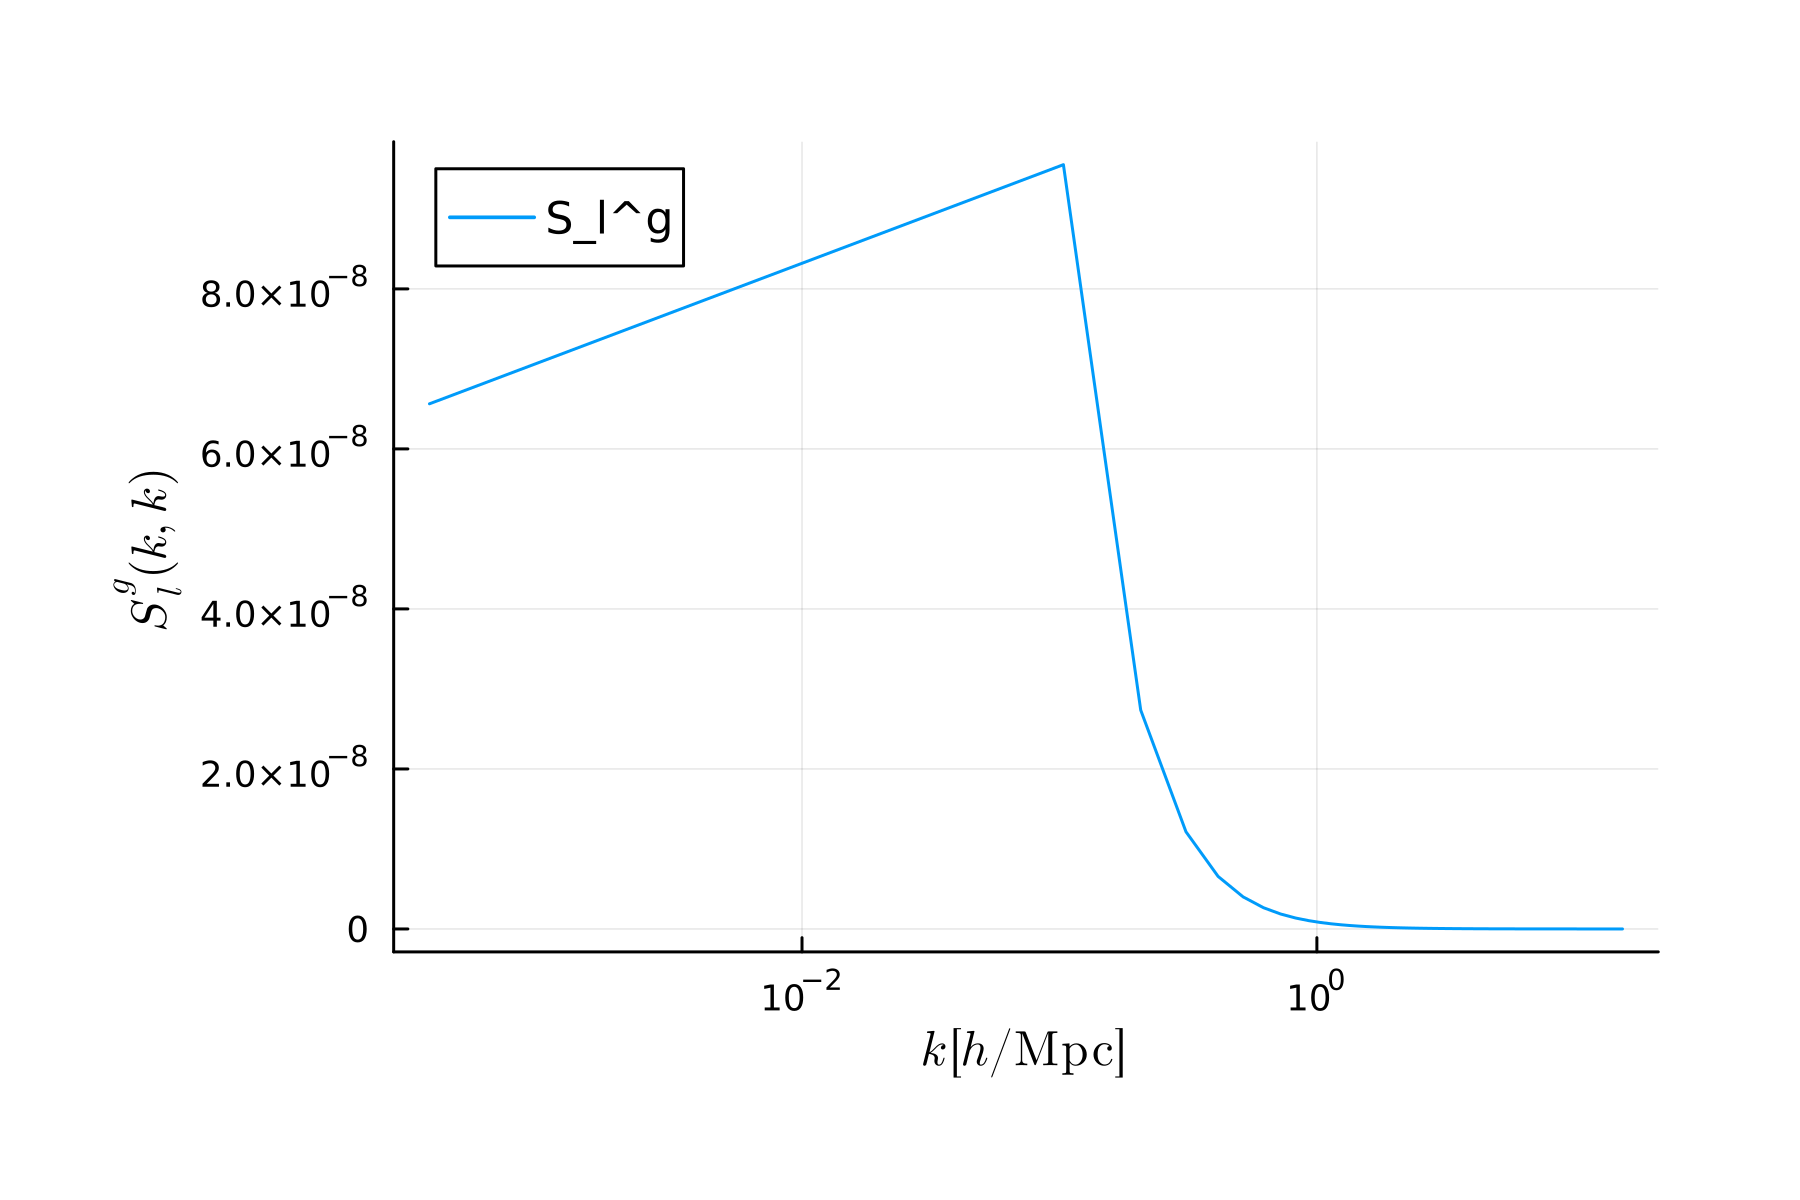

In [154]:
plot(k, Sval, label = "S_l^g", xlabel = L"k [h/\mathrm{Mpc}]", ylabel = L"S_l^g(k,k)", legend = :topleft; plot_theme.shared_style..., xscale = :log10)